# Collect Rollout Activations → HDF5

Generate multiple rollouts of the trained CNN gap-running agent and save:
- 4K third-person video per rollout
- Per-timestep neural activations at every layer (CNN features, fusion MLP, latent z, decoder)
- Observations (vision, task_obs) and actions
- Environment metadata (gap positions, rodent position, rewards)

All data saved to HDF5 using `track_mjx.analysis.utils.save_to_h5py`.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

import gc
import json
import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import h5py
from pathlib import Path
from omegaconf import OmegaConf

from track_mjx.agent import checkpointing
from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
from track_mjx.agent.ff_ppo.vision_encoder import VisionEncoder
from track_mjx.agent.ff_ppo.shared_vision_network import SharedVisionPolicyValueModule
from track_mjx.agent.observation_utils import (
    get_obs_sizes,
    init_dict_normalizer,
    normalize_dict_obs,
)
from track_mjx.agent.checkpointing import _replace_zero_sized_arrays
from track_mjx.analysis.utils import save_to_h5py
from vnl_playground import tasks
from vnl_playground.tasks.wrappers import HighLevelWrapper
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP
import orbax.checkpoint as ocp

print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")

JAX devices: [CudaDevice(id=0)]
JAX backend: gpu


In [2]:
CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/vnl-playground/"
    "highlvl_checkpoints/260215_091930_last10"
)
MIMIC_CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/track-mjx/model_checkpoints"
)
OUTPUT_DIR = CHECKPOINT_DIR.parent / "rollout_data"
OUTPUT_DIR.mkdir(exist_ok=True)

# Rollout settings
NUM_ROLLOUTS = 10
EPISODE_LENGTH = 500
BASE_SEED = 42

# 4K video settings
VIDEO_FPS = 50
VIDEO_HEIGHT = 2160
VIDEO_WIDTH = 3840

print(f"Output directory: {OUTPUT_DIR}")
print(f"Will collect {NUM_ROLLOUTS} rollouts of {EPISODE_LENGTH} steps each")

Output directory: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data
Will collect 10 rollouts of 500 steps each


## Load Config, Decoder, Environment, Network, Checkpoint

In [3]:
# Load checkpoint config
with open(CHECKPOINT_DIR / "config.json") as f:
    cfg_dict = json.load(f)
cfg = OmegaConf.create(cfg_dict)

# Load frozen decoder
mimic_ckpt_path = str(MIMIC_CHECKPOINT_DIR / cfg.transfer.mimic_run_id)
mimic_cfg = OmegaConf.create(checkpointing.load_config_from_checkpoint(mimic_ckpt_path))
decoder_policy_fn = ff_ppo_networks.make_decoder_policy_fn(mimic_ckpt_path)
latent_size = mimic_cfg.network_config.intention_size

# Load environment
env_args = (
    OmegaConf.to_container(cfg.env_config.get("env_args", {}), resolve=True) or {}
)
if hasattr(mimic_cfg, "env_config") and hasattr(mimic_cfg.env_config, "ctrl_dt"):
    env_args["ctrl_dt"] = float(mimic_cfg.env_config.ctrl_dt)

# Remap flat keys to their nested config paths
if "target_speed" in env_args:
    ts = env_args.pop("target_speed")
    env_args["reward_terms.forward_velocity.target_speed"] = ts

raw_env = tasks.load(
    cfg.env_config.env_name,
    flatten_obs=False,
    config_overrides=env_args if env_args else None,
)

# Get obs_sizes
highlvl_obs_key = cfg.transfer.get("highlvl_obs_key", "imitation_target")
decoder_obs_key = cfg.transfer.get("decoder_obs_key", "proprioception")
_tmp = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)
_tmp_state = _tmp.reset(jax.random.PRNGKey(99))
obs_sizes = get_obs_sizes(_tmp_state.obs)
del _tmp, _tmp_state

print(f"Environment: {cfg.env_config.env_name}")
print(f"Latent size: {latent_size}")
print(f"Obs sizes: {obs_sizes}")

Warp 1.12.0.dev20260222 initialized:
   Git commit: 46b17734a17b4663afc59b06f456f22fed81f23f
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.12.0.dev20260222
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 6.52 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.26 ms  (cached)
Module _nxn_broadphase__locals__kernel_ad5e5280 ad5e528 load on device 'cuda:0' took 0.26 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_20ba1e98 20ba1e9 load on device 'cuda:0' took 0.88 ms  (cached)
Module ccd_kernel_builde

In [4]:
# Recreate PPO network
vision_shape = (
    cfg.env_config.get("vision_height", 32),
    cfg.env_config.get("vision_width", 32),
    1 if cfg.env_config.get("grayscale", True) else 3,
)

ppo_network, shared_module = (
    ff_ppo_networks.make_shared_vision_task_obs_highlvl_ppo_networks(
        obs_sizes=obs_sizes,
        action_size=latent_size,
        vision_shape=vision_shape,
        vision_latent_size=cfg.network_config.vision_latent_size,
        vision_feature_size=cfg.network_config.get("vision_feature_size", 32),
        decoder_hidden_layer_sizes=tuple(cfg.network_config.decoder_hidden_layer_sizes),
        value_hidden_layer_sizes=tuple(cfg.network_config.value_hidden_layer_sizes),
        vision_channels=tuple(cfg.network_config.vision_channels),
        fusion_hidden_layer_sizes=tuple(
            cfg.network_config.get("fusion_hidden_layer_sizes", [256])
        ),
    )
)

# Load policy from checkpoint
ckpt_mgr = ocp.CheckpointManager(
    str(CHECKPOINT_DIR),
    options=ocp.CheckpointManagerOptions(
        save_interval_steps=1,
        max_to_keep=200,
        step_prefix="PPONetwork",
        create=False,
    ),
)
latest_step = ckpt_mgr.latest_step()

key_policy, _ = jax.random.split(jax.random.PRNGKey(0))
init_policy_params = ppo_network.policy_network.init(key_policy)
dummy_obs = {
    "imitation_target": jnp.zeros((1, obs_sizes["imitation_target"])),
    "proprioception": jnp.zeros((1, obs_sizes["proprioception"])),
}
abstract_policy = _replace_zero_sized_arrays(
    (init_dict_normalizer(dummy_obs), init_policy_params)
)

normalizer_params, policy_params = ckpt_mgr.restore(
    latest_step,
    args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
)["policy"]
params_tuple = (normalizer_params, policy_params)

print(f"Loaded checkpoint step {latest_step}")
print(f"Architecture: {cfg.network_config.arch_name}")
print(f"Vision shape: {vision_shape}")

Loaded checkpoint step 99
Architecture: shared_vision_task_obs
Vision shape: (32, 32, 1)


In [5]:
gc.collect()
jax.clear_caches()


def _add_batch_dim_for_warp(data):
    """Add leading batch dim to Data, skipping non-vmap fields."""

    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        if attr in DATA_NON_VMAP:
            return x
        return x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


# Vision renderer (32x32 for policy input)
vision_renderer = JaxVisionRenderer(
    mj_model=raw_env.mj_model,
    mjx_model=raw_env.mjx_model,
    nworld=1,
    width=cfg.env_config.get("vision_width", 32),
    height=cfg.env_config.get("vision_height", 32),
    grayscale=cfg.env_config.get("grayscale", True),
    camera_name=cfg.env_config.get("vision_camera_name", "egocentric-rodent"),
)

# HighLevelWrapper
eval_env = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)


def eval_reset(rng):
    state = eval_env.reset(rng)
    data_b = _add_batch_dim_for_warp(state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


def eval_step(state, action):
    state = eval_env.step(state, action)
    data_b = _add_batch_dim_for_warp(state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


# JIT compile
make_logging_policy = ff_ppo_networks.make_logging_inference_fn(ppo_network)
jit_inference_fn = jax.jit(make_logging_policy(deterministic=True))
jit_eval_reset = jax.jit(eval_reset)
jit_eval_step = jax.jit(eval_step)

print("Eval pipeline ready.")

Module update_gradient_JTDAJ_sparse_tiled__locals__kernel_5d7ef86b c2b6865 load on device 'cuda:0' took 39.77 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.render_util f631443 load on device 'cuda:0' took 0.39 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io 4ae9eac load on device 'cuda:0' took 1.70 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 302ba2e load on device 'cuda:0' took 0.64 ms  (cached)
Eval pipeline ready.


## Activation Extraction Functions

In [6]:
# Standalone vision encoder for manual activation extraction
standalone_encoder = VisionEncoder(
    feature_size=cfg.network_config.get("vision_feature_size", 32),
    channels=tuple(cfg.network_config.vision_channels),
)
vision_encoder_params = {"params": policy_params["params"]["vision_encoder"]}

CHANNELS = tuple(cfg.network_config.vision_channels)
STRIDES = (1, 1, 2, 2)
FUSION_LAYERS = tuple(cfg.network_config.get("fusion_hidden_layer_sizes", [256]))


def get_all_activations(obs_dict):
    """Extract all network activations from a single observation.

    Returns dict with:
        - cnn_features: (F,) CNN output vector (e.g. 32-dim)
        - conv_spatial: list of (H_i, W_i, C_i) arrays, one per conv layer
        - fusion_hiddens: list of (H,) arrays, one per fusion layer
        - latent_z: (Z,) intention vector (e.g. 16-dim)
        - decoder_hiddens: dict of per-layer decoder activations
        - task_obs: (T,) raw task observation
    """
    obs_b = {k: jnp.array(np.array(v))[None, ...] for k, v in obs_dict.items()}
    obs_normed = normalize_dict_obs(obs_b, normalizer_params)

    # Full forward with activation extraction
    action, latent_mean, latent_logvar, acts = shared_module.apply(
        policy_params,
        obs=obs_normed,
        key=jax.random.PRNGKey(0),
        get_activation=True,
        method="policy_forward",
    )

    # Conv spatial activations (per-layer feature maps)
    image = obs_dict["vision"]
    x = jnp.array(image).reshape(1, *image.shape[-3:])
    conv_spatial = []
    params = vision_encoder_params["params"]
    for i, (ch, stride) in enumerate(zip(CHANNELS, STRIDES)):
        kernel = params[f"conv_{i}"]["kernel"]
        bias = params[f"conv_{i}"]["bias"]
        x = (
            jax.lax.conv_general_dilated(
                x,
                kernel,
                window_strides=(stride, stride),
                padding="VALID",
                dimension_numbers=("NHWC", "HWIO", "NHWC"),
            )
            + bias
        )
        x = jax.nn.relu(x)
        conv_spatial.append(np.array(x[0]))

    # Extract fusion MLP hidden activations manually
    params = policy_params["params"]
    task_obs = obs_normed["imitation_target"]
    vision = obs_normed["vision"]
    vision_features = standalone_encoder.apply(vision_encoder_params, vision)

    combined = jnp.concatenate([vision_features, task_obs], axis=-1)
    z = combined
    fusion_hiddens = []
    for i in range(len(FUSION_LAYERS)):
        kernel = params[f"fusion_dense_{i}"]["kernel"]
        bias = params[f"fusion_dense_{i}"]["bias"]
        z = jax.nn.silu(z @ kernel + bias)
        ln_scale = params[f"fusion_norms_{i}"]["scale"]
        ln_bias = params[f"fusion_norms_{i}"]["bias"]
        mean = jnp.mean(z, axis=-1, keepdims=True)
        var = jnp.var(z, axis=-1, keepdims=True)
        z = (z - mean) / jnp.sqrt(var + 1e-5) * ln_scale + ln_bias
        fusion_hiddens.append(np.array(z[0]))

    return {
        "cnn_features": np.array(acts["vision_features"][0]),
        "conv_spatial": conv_spatial,
        "fusion_hiddens": fusion_hiddens,
        "latent_z": np.array(latent_mean[0]),
        "decoder_hiddens": {
            k: np.array(v[0]) for k, v in acts.get("decoder", {}).items()
        },
        "task_obs": np.array(
            obs_dict.get("imitation_target", obs_b.get("imitation_target", []))
        ),
    }


print(f"Activation extraction ready.")
print(f"  CNN channels: {CHANNELS}")
print(f"  Fusion layers: {FUSION_LAYERS}")

Activation extraction ready.
  CNN channels: (4, 8, 16, 32)
  Fusion layers: (256, 256, 256)


## Single Rollout Collection

Runs one episode, collecting per-timestep:
- qpos (joint positions)
- egocentric vision frames (32x32)
- actions (latent space commands)
- rewards
- rodent x-position
- all network activations (conv spatial maps, CNN features, fusion hiddens, latent z, decoder hiddens)

In [7]:
def run_single_rollout(seed, episode_length=EPISODE_LENGTH):
    """Run a single rollout and collect all data.

    Args:
        seed: Random seed for this rollout.
        episode_length: Number of environment steps.

    Returns:
        Dict with all collected data (numpy arrays).
    """
    eval_rng = jax.random.PRNGKey(seed)
    state = jit_eval_reset(eval_rng)
    act_rng = jax.random.PRNGKey(seed + 1000)

    # Pre-allocate storage
    qpos_list = [np.array(state.data.qpos)]
    ego_frames = [np.array(state.obs["vision"])]
    actions_list = []
    rewards = []
    rodent_x = [float(state.data.qpos[raw_env._rodent_qpos_start - 7])]

    # Activation storage
    cnn_features_list = []
    conv_spatial_list = {i: [] for i in range(len(CHANNELS))}
    fusion_hiddens_list = {i: [] for i in range(len(FUSION_LAYERS))}
    latent_z_list = []
    decoder_hiddens_keys = None
    decoder_hiddens_list = {}
    task_obs_list = []

    def _store_activations(acts):
        cnn_features_list.append(acts["cnn_features"])
        for i, cs in enumerate(acts["conv_spatial"]):
            conv_spatial_list[i].append(cs)
        for i, fh in enumerate(acts["fusion_hiddens"]):
            fusion_hiddens_list[i].append(fh)
        latent_z_list.append(acts["latent_z"])
        task_obs_list.append(acts["task_obs"])

    # Step 0 activations
    acts_0 = get_all_activations(state.obs)
    _store_activations(acts_0)
    if acts_0["decoder_hiddens"]:
        decoder_hiddens_keys = sorted(acts_0["decoder_hiddens"].keys())
        for k in decoder_hiddens_keys:
            decoder_hiddens_list[k] = [acts_0["decoder_hiddens"][k]]

    # Rollout loop
    for step in range(episode_length):
        _, act_rng = jax.random.split(act_rng)
        action, extras = jit_inference_fn(params_tuple, state.obs, act_rng)
        state = jit_eval_step(state, action)

        # Record basic data
        qpos_list.append(np.array(state.data.qpos))
        ego_frames.append(np.array(state.obs["vision"]))
        actions_list.append(np.array(action))
        rewards.append(float(state.reward))
        rodent_x.append(float(state.data.qpos[raw_env._rodent_qpos_start - 7]))

        # Extract all activations
        acts = get_all_activations(state.obs)
        _store_activations(acts)
        if decoder_hiddens_keys:
            for k in decoder_hiddens_keys:
                decoder_hiddens_list[k].append(acts["decoder_hiddens"][k])

        if (step + 1) % 100 == 0:
            print(f"    Step {step+1}/{episode_length}, cum_reward={sum(rewards):.2f}")

    # Extract gap positions from final state
    platform_body_ids = raw_env._platform_body_ids
    platform_half_length = raw_env._platform_half_length
    start_platform_body_id = raw_env._start_platform_body_id
    start_platform_half_length = raw_env._start_platform_half_length

    plat_centers = np.array(state.data.xpos[platform_body_ids, 0])
    plat_starts = plat_centers - platform_half_length
    plat_ends = plat_centers + platform_half_length
    start_end = (
        float(state.data.xpos[start_platform_body_id, 0]) + start_platform_half_length
    )
    gap_starts = np.concatenate([[start_end], plat_ends[:-1]])
    gap_ends = plat_starts

    # Assemble result dict
    result = {
        "qpos": np.array(qpos_list),
        "ego_vision": np.array(ego_frames),
        "actions": np.array(actions_list),
        "rewards": np.array(rewards),
        "rodent_x": np.array(rodent_x),
        "cnn_features": np.array(cnn_features_list),
        "latent_z": np.array(latent_z_list),
        "task_obs": np.array(task_obs_list),
        "gap_starts": gap_starts,
        "gap_ends": gap_ends,
        "seed": seed,
        "episode_length": episode_length,
        "total_reward": sum(rewards),
    }

    # Add conv spatial maps (all timesteps)
    for layer_idx in range(len(CHANNELS)):
        result[f"conv_{layer_idx}_spatial"] = np.array(conv_spatial_list[layer_idx])

    # Add fusion hiddens
    for i in range(len(FUSION_LAYERS)):
        result[f"fusion_hidden_{i}"] = np.array(fusion_hiddens_list[i])

    # Add decoder hiddens
    if decoder_hiddens_keys:
        for k in decoder_hiddens_keys:
            result[f"decoder_{k}"] = np.array(decoder_hiddens_list[k])

    return result


print("run_single_rollout() defined.")

run_single_rollout() defined.


## 4K Video Rendering

Render a 4K (3840x2160) third-person video with egocentric vision overlay
for each rollout using the MuJoCo CPU renderer.

In [8]:
import imageio


def render_4k_video(qpos_list, ego_frames, output_path, fps=VIDEO_FPS):
    """Render a 4K third-person video with egocentric overlay.

    Args:
        qpos_list: List/array of qpos per timestep, shape (T+1, qpos_dim).
        ego_frames: List/array of ego vision frames, shape (T+1, H, W, C).
        output_path: Path to save the MP4 file.
        fps: Video frame rate.
    """
    mj_model = raw_env.mj_model
    mj_data = mujoco.MjData(mj_model)
    renderer = mujoco.Renderer(mj_model, height=VIDEO_HEIGHT, width=VIDEO_WIDTH)

    camera = mujoco.MjvCamera()
    camera.type = mujoco.mjtCamera.mjCAMERA_TRACKING
    for name in ["torso-rodent", "torso"]:
        try:
            camera.trackbodyid = mj_model.body(name).id
            break
        except Exception:
            continue
    camera.distance = 1.0
    camera.azimuth = 90
    camera.elevation = -20
    camera.lookat[:] = [0, 0, 0.3]

    def overlay_ego(frame, ego_img, scale=6):
        """Overlay scaled egocentric image on upper-left of frame."""
        img = (np.clip(ego_img, 0, 1) * 255).astype(np.uint8)
        if img.ndim == 2:
            img = img[:, :, None]
        if img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)
        img = np.repeat(np.repeat(img, scale, axis=0), scale, axis=1)
        sh, sw = img.shape[:2]
        pad = 6
        y0, x0 = pad + 8, pad + 8
        y1, x1 = y0 + sh, x0 + sw
        out = frame.copy()
        if y1 + pad < out.shape[0] and x1 + pad < out.shape[1]:
            out[y0 - pad : y1 + pad, x0 - pad : x1 + pad] = 255
            out[y0:y1, x0:x1] = img
        return out

    n_frames = len(qpos_list)
    writer = imageio.get_writer(
        output_path,
        fps=fps,
        codec="libx264",
        output_params=["-crf", "18", "-preset", "slow"],
    )

    print(f"  Rendering {n_frames} frames at {VIDEO_WIDTH}x{VIDEO_HEIGHT}...")
    for t in range(n_frames):
        mj_data.qpos = np.array(qpos_list[t])
        mujoco.mj_forward(mj_model, mj_data)
        renderer.update_scene(mj_data, camera)
        frame = renderer.render().copy()
        frame = overlay_ego(frame, ego_frames[t])
        writer.append_data(frame)
        if (t + 1) % 100 == 0:
            print(f"    Frame {t+1}/{n_frames}")

    writer.close()
    renderer.close()
    print(f"  Video saved: {output_path}")


print("render_4k_video() defined.")

render_4k_video() defined.


## Collect Multiple Rollouts

Run N rollouts with different seeds, save each to HDF5, and render 4K video.

In [9]:
rollout_summaries = []

for rollout_idx in range(NUM_ROLLOUTS):
    seed = BASE_SEED + rollout_idx
    print(f"\n{'='*60}")
    print(f"Rollout {rollout_idx+1}/{NUM_ROLLOUTS} (seed={seed})")
    print(f"{'='*60}")

    # Run rollout
    data = run_single_rollout(seed)
    print(f"  Total reward: {data['total_reward']:.2f}")
    print(
        f"  Rodent x-range: [{data['rodent_x'].min():.2f}, {data['rodent_x'].max():.2f}]"
    )

    # Save to HDF5
    h5_path = OUTPUT_DIR / f"rollout_{rollout_idx:03d}_seed{seed}.h5"
    save_to_h5py(h5_path, data)
    print(f"  HDF5 saved: {h5_path}")

    # Render 4K video
    video_path = OUTPUT_DIR / f"rollout_{rollout_idx:03d}_seed{seed}_4k.mp4"
    render_4k_video(data["qpos"], data["ego_vision"], str(video_path))

    rollout_summaries.append(
        {
            "rollout_idx": rollout_idx,
            "seed": seed,
            "total_reward": data["total_reward"],
            "x_max": float(data["rodent_x"].max()),
            "h5_path": str(h5_path),
            "video_path": str(video_path),
        }
    )

    # Free memory
    del data
    gc.collect()

print(f"\n{'='*60}")
print(f"All {NUM_ROLLOUTS} rollouts complete!")
print(f"{'='*60}")


Rollout 1/10 (seed=42)
Module render__locals___render_megakernel_be41967f be41967 load on device 'cuda:0' took 0.82 ms  (cached)
    Step 100/500, cum_reward=35.29
    Step 200/500, cum_reward=73.58
    Step 300/500, cum_reward=108.77
    Step 400/500, cum_reward=144.54
    Step 500/500, cum_reward=161.72
  Total reward: 161.72
  Rodent x-range: [0.50, 3.71]
  HDF5 saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_000_seed42.h5
  Rendering 501 frames at 3840x2160...


/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


    Frame 100/501
    Frame 200/501
    Frame 300/501
    Frame 400/501
    Frame 500/501
  Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_000_seed42_4k.mp4

Rollout 2/10 (seed=43)
    Step 100/500, cum_reward=36.02
    Step 200/500, cum_reward=-210.53
    Step 300/500, cum_reward=-1209.98
    Step 400/500, cum_reward=-2209.98
    Step 500/500, cum_reward=-3209.98
  Total reward: -3209.98
  Rodent x-range: [0.50, 1.74]
  HDF5 saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_001_seed43.h5
  Rendering 501 frames at 3840x2160...


/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


    Frame 100/501
    Frame 200/501
    Frame 300/501
    Frame 400/501
    Frame 500/501
  Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_001_seed43_4k.mp4

Rollout 3/10 (seed=44)
    Step 100/500, cum_reward=36.17
    Step 200/500, cum_reward=73.22
    Step 300/500, cum_reward=-183.41
    Step 400/500, cum_reward=-1181.15
    Step 500/500, cum_reward=-2178.74
  Total reward: -2178.74
  Rodent x-range: [0.50, 2.50]
  HDF5 saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_002_seed44.h5
  Rendering 501 frames at 3840x2160...


...

    Frame 100/501
    Frame 200/501
    Frame 300/501
    Frame 400/501
    Frame 500/501
  Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_007_seed49_4k.mp4

Rollout 9/10 (seed=50)
    Step 100/500, cum_reward=35.20
    Step 200/500, cum_reward=72.17
    Step 300/500, cum_reward=109.26
    Step 400/500, cum_reward=-207.22
    Step 500/500, cum_reward=-1206.94
  Total reward: -1206.94
  Rodent x-range: [0.50, 3.13]
  HDF5 saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_008_seed50.h5
  Rendering 501 frames at 3840x2160...


/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


    Frame 100/501
    Frame 200/501
    Frame 300/501
    Frame 400/501
    Frame 500/501
  Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_008_seed50_4k.mp4

Rollout 10/10 (seed=51)
    Step 100/500, cum_reward=36.05
    Step 200/500, cum_reward=76.02
    Step 300/500, cum_reward=113.04
    Step 400/500, cum_reward=66.79
    Step 500/500, cum_reward=-928.54
  Total reward: -928.54
  Rodent x-range: [0.50, 3.37]
  HDF5 saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_009_seed51.h5
  Rendering 501 frames at 3840x2160...


/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


    Frame 100/501
    Frame 200/501
    Frame 300/501
    Frame 400/501
    Frame 500/501
  Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_009_seed51_4k.mp4

All 10 rollouts complete!


In [10]:
# Print summary table
print(f"\n{'Rollout':<10} {'Seed':<8} {'Reward':<12} {'X Max':<10}")
print("-" * 40)
for s in rollout_summaries:
    print(
        f"{s['rollout_idx']:<10} {s['seed']:<8} {s['total_reward']:<12.2f} {s['x_max']:<10.2f}"
    )

# Save metadata JSON
import json as json_mod

meta_path = OUTPUT_DIR / "rollout_metadata.json"
with open(meta_path, "w") as f:
    json_mod.dump(
        {
            "checkpoint_dir": str(CHECKPOINT_DIR),
            "checkpoint_step": int(latest_step),
            "arch_name": cfg.network_config.arch_name,
            "vision_shape": list(vision_shape),
            "episode_length": EPISODE_LENGTH,
            "num_rollouts": NUM_ROLLOUTS,
            "base_seed": BASE_SEED,
            "video_resolution": [VIDEO_WIDTH, VIDEO_HEIGHT],
            "rollouts": rollout_summaries,
        },
        f,
        indent=2,
    )
print(f"\nMetadata saved: {meta_path}")


Rollout    Seed     Reward       X Max     
----------------------------------------
0          42       161.72       3.71      
1          43       -3209.98     1.74      
2          44       -2178.74     2.50      
3          45       -284.76      3.88      
4          46       -3176.74     2.35      
5          47       -2819.60     1.73      
6          48       168.37       3.91      
7          49       175.71       4.02      
8          50       -1206.94     3.13      
9          51       -928.54      3.37      

Metadata saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_data/rollout_metadata.json


In [11]:
# Verify one HDF5 file
test_path = OUTPUT_DIR / f"rollout_000_seed{BASE_SEED}.h5"
with h5py.File(test_path, "r") as f:
    print(f"HDF5 contents of {test_path.name}:")

    def print_h5(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")

    f.visititems(print_h5)

HDF5 contents of rollout_000_seed42.h5:
  actions: shape=(500, 16), dtype=float32
  cnn_features: shape=(501, 32), dtype=float32
  conv_0_spatial: shape=(501, 30, 30, 4), dtype=float32
  conv_1_spatial: shape=(501, 28, 28, 8), dtype=float32
  conv_2_spatial: shape=(501, 13, 13, 16), dtype=float32
  conv_3_spatial: shape=(501, 6, 6, 32), dtype=float32
  decoder_layer_0: shape=(501, 512), dtype=float32
  decoder_layer_1: shape=(501, 512), dtype=float32
  decoder_layer_2: shape=(501, 512), dtype=float32
  ego_vision: shape=(501, 32, 32, 1), dtype=float32
  episode_length: shape=(), dtype=int64
  fusion_hidden_0: shape=(501, 256), dtype=float32
  fusion_hidden_1: shape=(501, 256), dtype=float32
  fusion_hidden_2: shape=(501, 256), dtype=float32
  gap_ends: shape=(20,), dtype=float32
  gap_starts: shape=(20,), dtype=float64
  latent_z: shape=(501, 16), dtype=float32
  qpos: shape=(501, 94), dtype=float32
  rewards: shape=(500,), dtype=float64
  rodent_x: shape=(501,), dtype=float64
  seed: 

## Quick Preview

Load one rollout from HDF5 and display a filmstrip + activation summary
to verify data integrity.

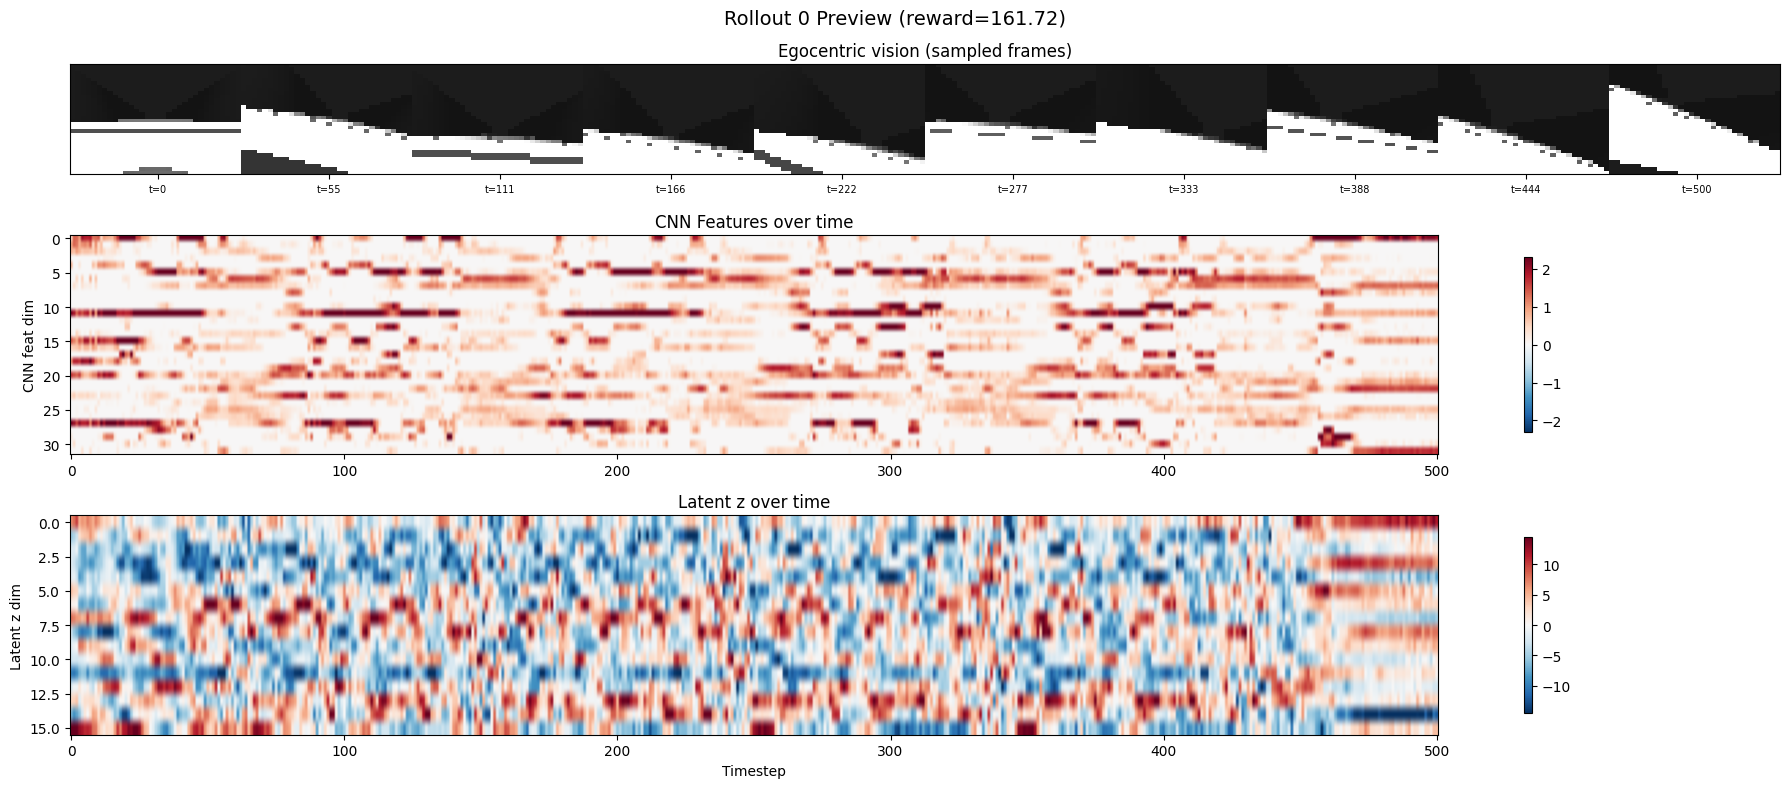

In [12]:
import matplotlib.pyplot as plt
from track_mjx.analysis.utils import load_from_h5py

# Load first rollout
preview_data = load_from_h5py(OUTPUT_DIR / f"rollout_000_seed{BASE_SEED}.h5")

fig, axes = plt.subplots(
    3, 1, figsize=(18, 8), gridspec_kw={"height_ratios": [1, 2, 2]}
)

# Row 0: ego vision filmstrip (10 evenly spaced frames)
n_show = 10
show_steps = np.linspace(0, EPISODE_LENGTH, n_show, dtype=int)
strip = np.concatenate(
    [preview_data["ego_vision"][s, :, :, 0] for s in show_steps], axis=1
)
axes[0].imshow(strip, cmap="gray", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(np.arange(n_show) * 32 + 16)
axes[0].set_xticklabels([f"t={s}" for s in show_steps], fontsize=7)
axes[0].set_yticks([])
axes[0].set_title("Egocentric vision (sampled frames)")

# Row 1: CNN features heatmap
im1 = axes[1].imshow(
    preview_data["cnn_features"].T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.percentile(np.abs(preview_data["cnn_features"]), 98),
    vmax=np.percentile(np.abs(preview_data["cnn_features"]), 98),
)
axes[1].set_ylabel("CNN feat dim")
axes[1].set_title("CNN Features over time")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Row 2: Latent z heatmap
im2 = axes[2].imshow(
    preview_data["latent_z"].T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.percentile(np.abs(preview_data["latent_z"]), 98),
    vmax=np.percentile(np.abs(preview_data["latent_z"]), 98),
)
axes[2].set_ylabel("Latent z dim")
axes[2].set_xlabel("Timestep")
axes[2].set_title("Latent z over time")
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.suptitle(
    f"Rollout 0 Preview (reward={preview_data['total_reward']:.2f})", fontsize=14
)
plt.tight_layout()
plt.show()

del preview_data

In [13]:
import zipfile

zip_path = Path("/home/talmolab/Desktop/SalkResearch/vnl-playground/notebooks/rollout_data.zip")
h5_files = sorted(OUTPUT_DIR.glob("*.h5"))
mp4_files = sorted(OUTPUT_DIR.glob("*.mp4"))
all_files = h5_files + mp4_files

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in all_files:
        print(f"  Adding {f.name}...")
        zf.write(f, f.name)

zip_size_mb = zip_path.stat().st_size / (1024 * 1024)
total_mb = sum(f.stat().st_size for f in all_files) / (1024 * 1024)
print(f"\nZipped {len(all_files)} files ({len(h5_files)} h5 + {len(mp4_files)} mp4): {total_mb:.1f} MB -> {zip_size_mb:.1f} MB")
print(f"Saved to: {zip_path}")

  Adding rollout_000_seed42.h5...
  Adding rollout_001_seed43.h5...
  Adding rollout_002_seed44.h5...
  Adding rollout_003_seed45.h5...
  Adding rollout_004_seed46.h5...
  Adding rollout_005_seed47.h5...
  Adding rollout_006_seed48.h5...
  Adding rollout_007_seed49.h5...
  Adding rollout_008_seed50.h5...
  Adding rollout_009_seed51.h5...
  Adding rollout_000_seed42_4k.mp4...
  Adding rollout_001_seed43_4k.mp4...
  Adding rollout_002_seed44_4k.mp4...
  Adding rollout_003_seed45_4k.mp4...
  Adding rollout_004_seed46_4k.mp4...
  Adding rollout_005_seed47_4k.mp4...
  Adding rollout_006_seed48_4k.mp4...
  Adding rollout_007_seed49_4k.mp4...
  Adding rollout_008_seed50_4k.mp4...
  Adding rollout_009_seed51_4k.mp4...

Zipped 20 files (10 h5 + 10 mp4): 409.0 MB -> 147.1 MB
Saved to: /home/talmolab/Desktop/SalkResearch/vnl-playground/notebooks/rollout_data.zip
